# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

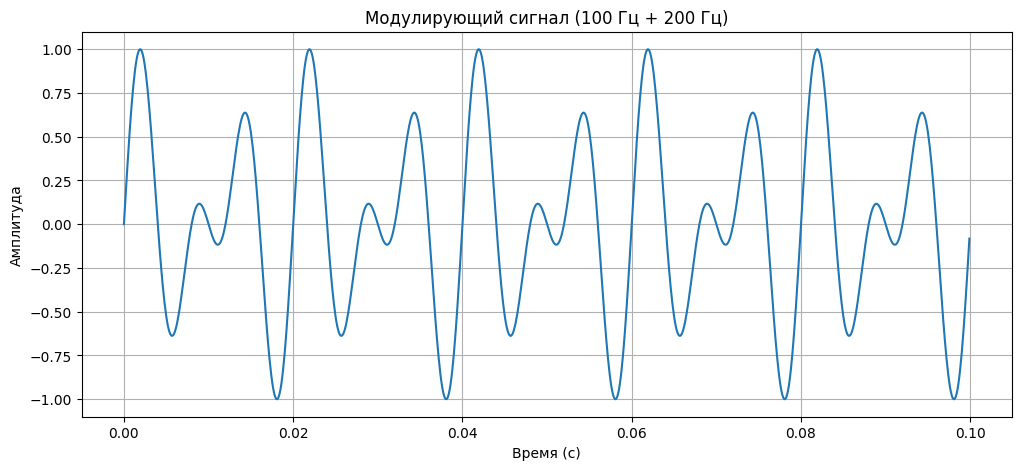

In [68]:
fm1 = 100
fm2 = 150
m_t = np.sin(2 * np.pi * fm1 * t) + np.sin(2 * np.pi * fm2 * t) # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]
m_t = m_t / np.max(np.abs(m_t))

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [69]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2 * np.pi * fc * t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [70]:
beta_pm = 5
s_pm = Ac * np.cos(2 * np.pi * fc * t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

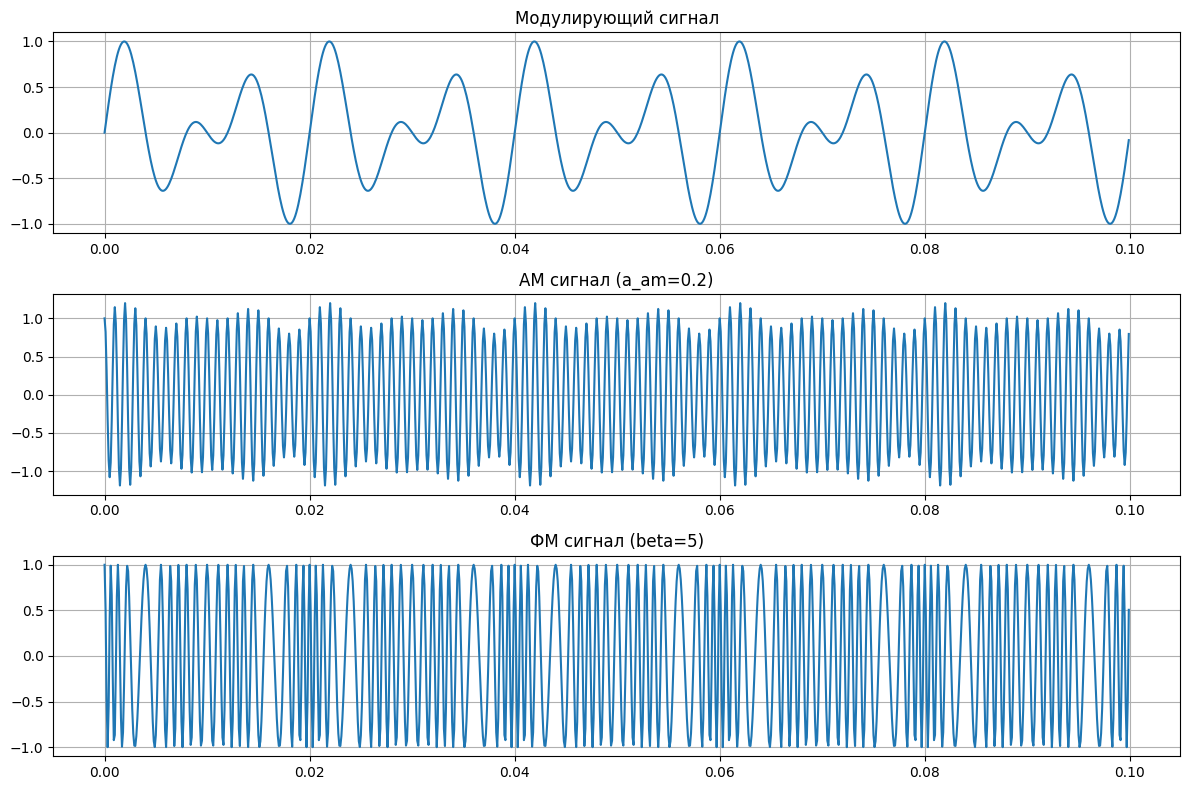

In [71]:
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, m_t)
plt.title('Модулирующий сигнал')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, s_am)
plt.title(f'АМ сигнал (a_am={a_am})')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, s_pm)
plt.title(f'ФМ сигнал (beta={beta_pm})')
plt.grid(True)
plt.tight_layout()
plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [72]:
def plot_spectrum(s, fs, title):
    n = len(s)
    spectrum = np.abs(np.fft.rfft(s)) / (n / 2)
    freqs = np.fft.rfftfreq(n, 1/fs)

    plt.plot(freqs, spectrum)
    plt.title(title)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.xlim(0, fc + 500)


### 2.2. Спектр АМ

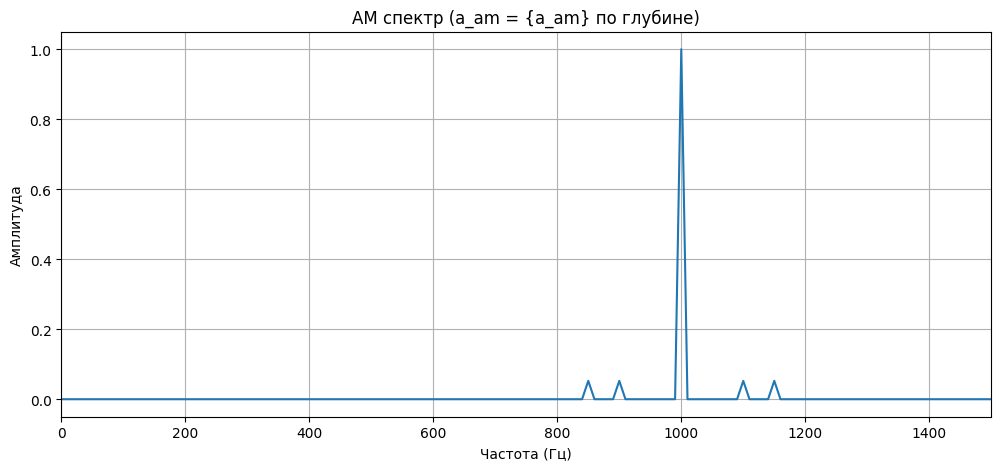

In [73]:
plot_spectrum(s_am, fs, 'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

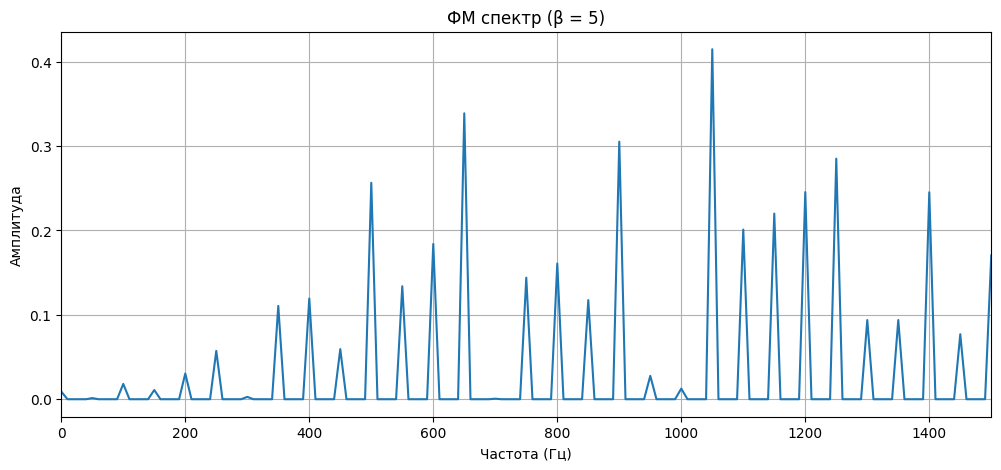

In [74]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

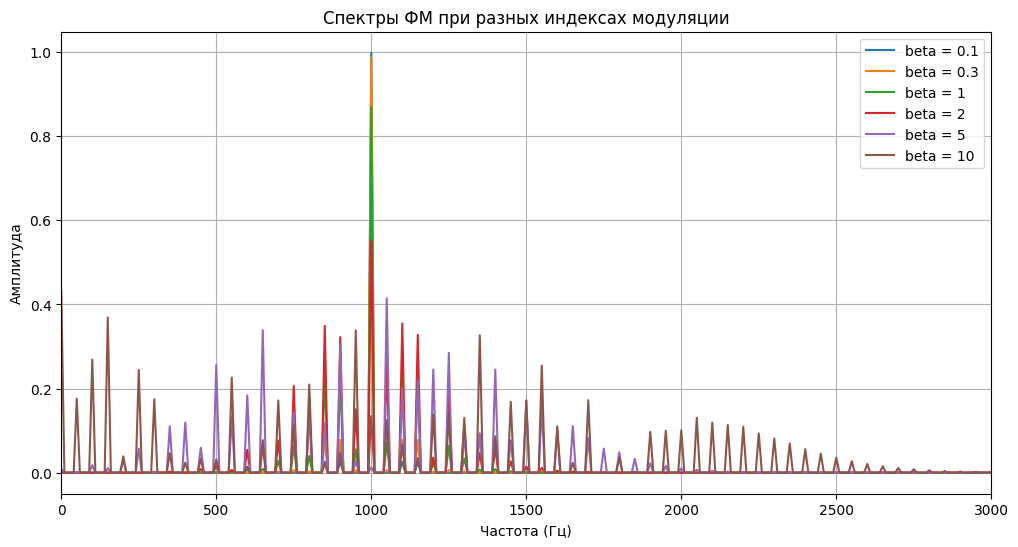

In [75]:
betas = [0.1, 0.3, 1, 2, 5, 10]
plt.figure(figsize=(12, 6))

for b in betas:
    s_pm_temp = Ac * np.cos(2 * np.pi * fc * t + b * m_t)

    n = len(s_pm_temp)
    spectrum = np.abs(np.fft.rfft(s_pm_temp)) / (n / 2)
    freqs = np.fft.rfftfreq(n, 1/fs)

    plt.plot(freqs, spectrum, label=f'beta = {b}')

plt.title('Спектры ФМ при разных индексах модуляции')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, fc + 2000)
plt.legend()
plt.grid(True)
plt.show()

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [76]:
def pm_spectrum(beta=5):
    s_pm_interactive = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)

    plt.figure(figsize=(12, 5))
    plot_spectrum(s_pm_interactive, fs, f'Спектр ФМ (beta = {beta})')
    plt.xlim(0, fc + 2500)
    plt.show()

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

Cигнал m(t) состоит из двух частот (100, 150 Гц). Спектр АМ содержит несущую частоту fc и по две боковые полосы для каждой частоты сообщения fc +- f_m1 и fc +- f_m2. 1+2+2 =5
При малых β спектр ФМ становится похож на спектр АМ, доминирует несущая и первые боковые гармоники.
При увеличении β энергия перераспределяется из несущей в боковые полосы. Амплитуда несущей может упасть до нуля, а количество боковых полос увеличивается.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

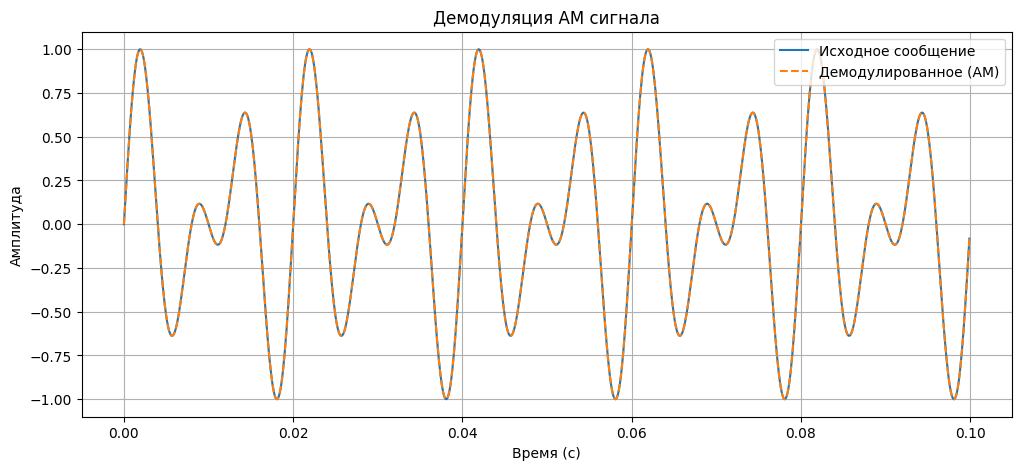

In [77]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [78]:
rmse_am = np.std(m_t - demod_am)
print(f"СКО АМ: {rmse_am:.7f}")

СКО АМ: 0.0000000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

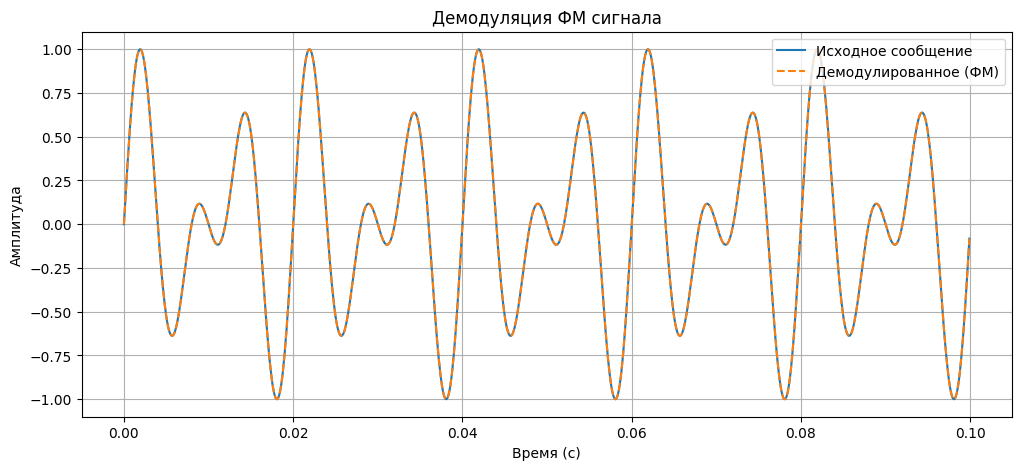

In [79]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

При вычислении фазы через `np.angle` результат лежит в пределах $[-\pi, \pi]$. Если истинная фаза пересекает эти границы, возникают скачки на $2\pi$. `np.unwrap` добавляет или вычитает $2\pi$ в местах скачков, восстанавливая непрерывную фазу.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [80]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-03-30 01:00:24--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-03-30 01:00:24--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.09s   

2026-03-30 01:00:25 (5.94 MB/s) - ‘audio.wav’ saved [563756/563756]



In [81]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

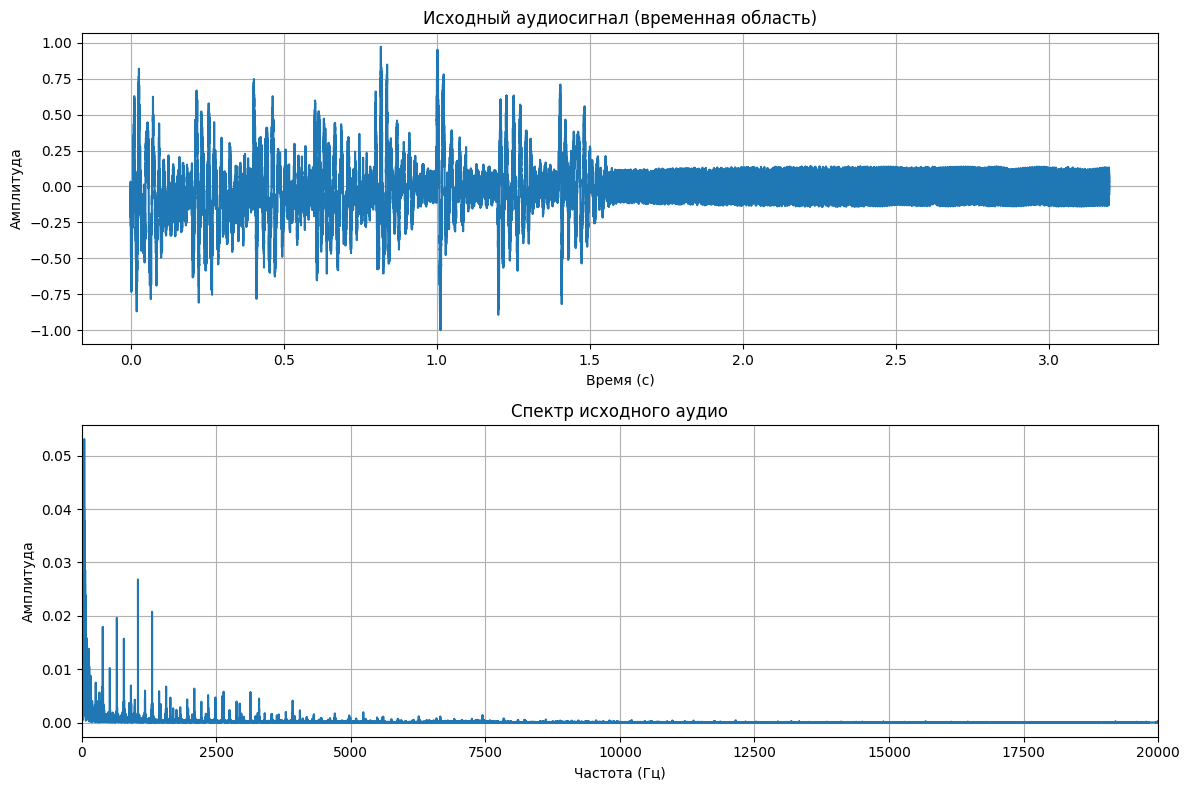

In [82]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_audio, melody)
plt.title('Исходный аудиосигнал (временная область)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2, 1, 2)
plot_spectrum(melody, fs_audio, 'Спектр исходного аудио')
plt.xlim(0, 20000)
plt.tight_layout()
plt.show()

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

Заметные пики наблюдаются до 5000Гц. После 10000Гц амплитуда спектра становится малой. Оптимальным выбором будет частота несущей около 10000-15000 Гц

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [83]:
fc_high = 12000
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [84]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [85]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [86]:
env_noisy = np.abs(hilbert(s_am_noisy))
demod_am_noisy = (env_noisy - 1) / a_am


Демодулируйте зашумлёный АМ-сигнал.

In [87]:
print("АМ с шумом:")
display(Audio(demod_am_noisy, rate=fs_audio))

АМ с шумом:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.



*   При демодуляции без шума качество звука практически не меняется
*   При фиксированной глубине модуляции $0.2$ сигнал составляет лишь малую часть амплитуды несущей.
*   При  малых $a_{AM}$ шум будет слышен отчетливо. По мере увеличения $a_{AM}$ до 0.8–1.0 отношение сигнал/шум улучшается, и искажения становятся менее заметными.






**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [88]:
phase_noisy = np.unwrap(np.angle(hilbert(s_pm_noisy)))
demod_pm_noisy = (phase_noisy - 2 * np.pi * fc_high * t_audio)
demod_pm_noisy = (demod_pm_noisy - np.mean(demod_pm_noisy)) / beta_pm_audio



Демодулируйте зашумлёный ФМ-сигнал.

In [89]:
print("ФМ с шумом:")
display(Audio(demod_pm_noisy, rate=fs_audio))

ФМ с шумом:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?


*   Качество звука ФМ без шума выше, так как фазовая модуляция менее чувствительна к линейным искажениям амплитуды
*   ФМ гораздо устойчивее к амплитудному шуму. Заметные искажения обычно проявляются при значительно более высоких уровнях шума, около 0.2–0.4, чем в АМ.

*   С ростом индекса модуляции $\beta$ помехоустойчивость ФМ растет. При малых $\beta$ сигнал сильно зашумлен, а при больших $\beta$ шум  подавляется при демодуляции.




### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

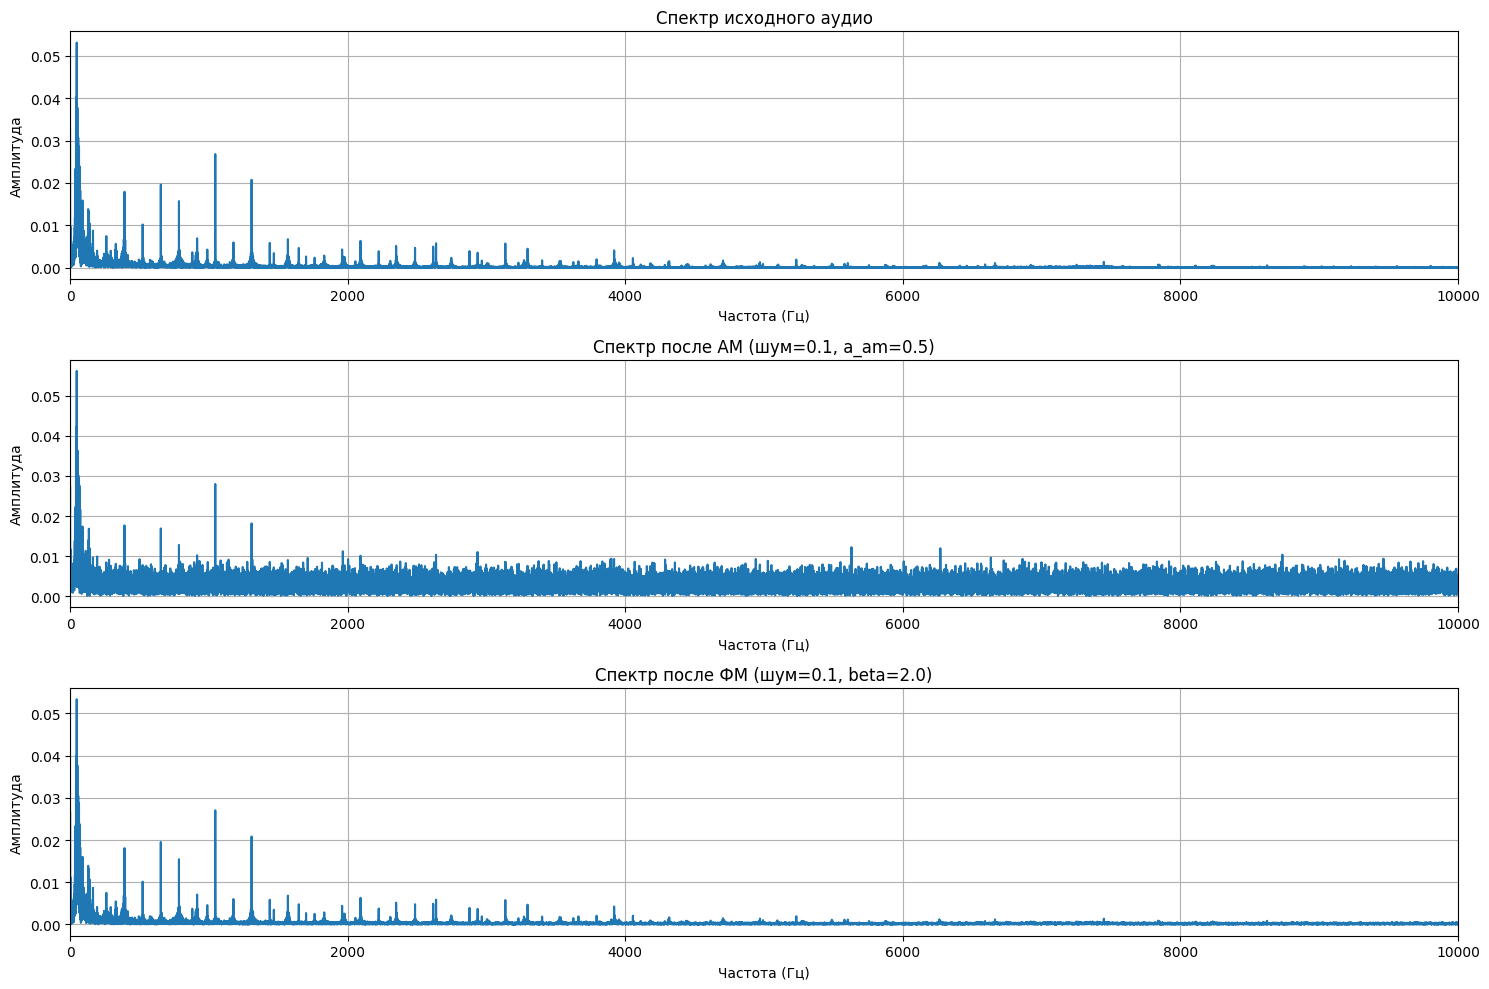

In [90]:
a_am_val = 0.5
beta_val = 2.0
noise_val = 0.1

plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plot_spectrum(melody, fs_audio, 'Спектр исходного аудио')
plt.xlim(0, 10000)

plt.subplot(3, 1, 2)
plot_spectrum(demod_am_noisy, fs_audio, f'Спектр после АМ (шум={noise_val}, a_am={a_am_val})')
plt.xlim(0, 10000)

plt.subplot(3, 1, 3)
plot_spectrum(demod_pm_noisy, fs_audio, f'Спектр после ФМ (шум={noise_val}, beta={beta_val})')
plt.xlim(0, 10000)
plt.tight_layout()
plt.show()

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

АМ: Искажения выражены сильнее. На графике виден высокий уровень шума. ФМ:
Искажения спектра выражены гораздо слабее. При том же уровне шума «шумовая полка» на графике ФМ находится ниже, спектр выглядит более чистым


Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

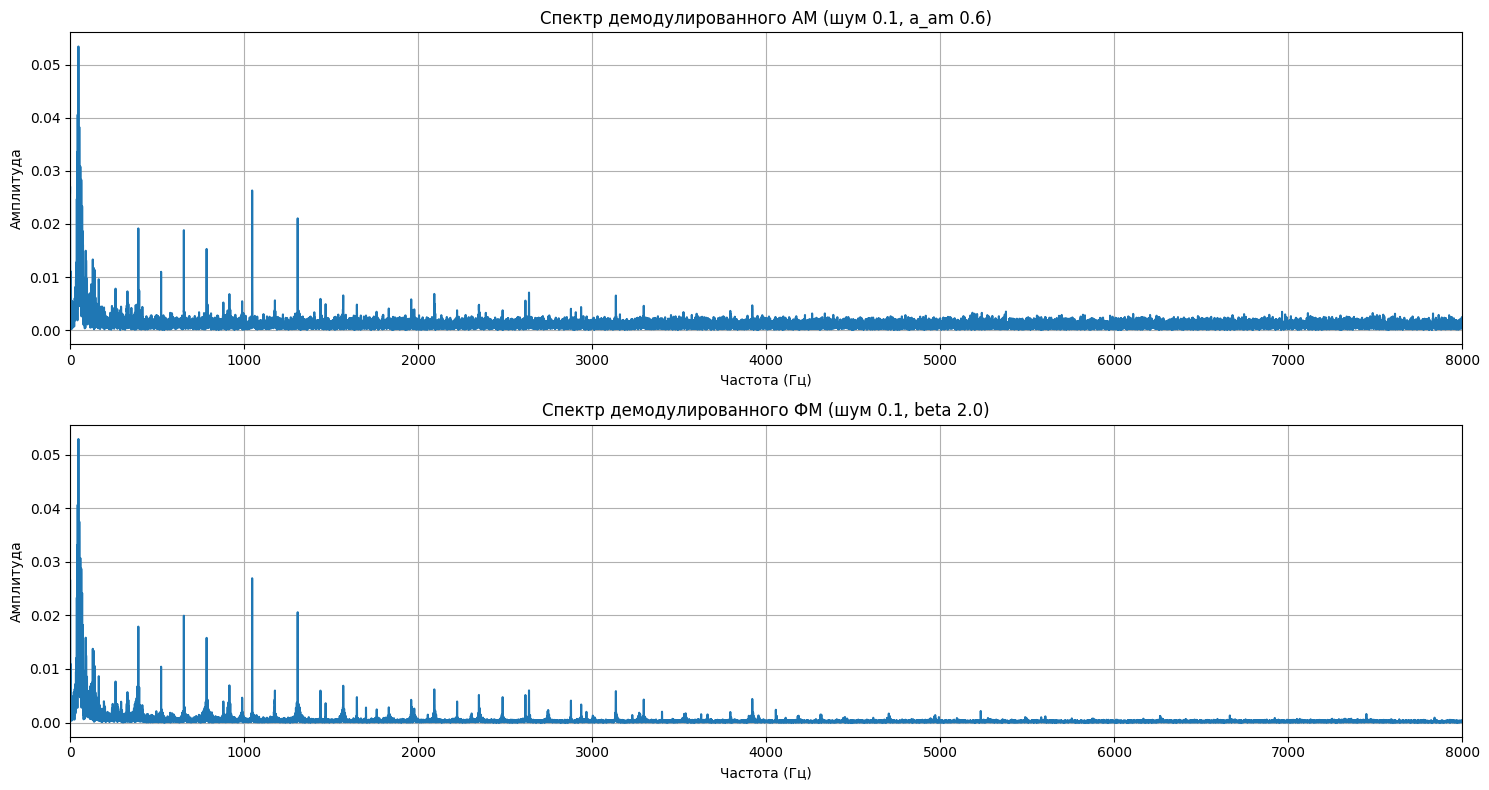

In [91]:
beta_final = 2.0
a_am_final = 0.6
amplitude_noise = 0.1

s_am_comp = Ac * (1 + a_am_final * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_comp = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_final * melody)

noise_comp = amplitude_noise * np.random.randn(len(t_audio))
s_am_noisy_comp = s_am_comp * (1 + noise_comp)
s_pm_noisy_comp = s_pm_comp * (1 + noise_comp)

env_noisy_comp = np.abs(hilbert(s_am_noisy_comp))
demod_am_final = (env_noisy_comp - 1) / a_am_final

phase_noisy_comp = np.unwrap(np.angle(hilbert(s_pm_noisy_comp)))
demod_pm_final = (phase_noisy_comp - 2 * np.pi * fc_high * t_audio)
demod_pm_final = (demod_pm_final - np.mean(demod_pm_final)) / beta_final

plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plot_spectrum(demod_am_final, fs_audio, f'Спектр демодулированного АМ (шум {amplitude_noise}, a_am {a_am_final})')
plt.xlim(0, 8000)

plt.subplot(2, 1, 2)
plot_spectrum(demod_pm_final, fs_audio, f'Спектр демодулированного ФМ (шум {amplitude_noise}, beta {beta_final})')
plt.xlim(0, 8000)
plt.tight_layout()
plt.show()

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

В АМ-сигнале шум становится отчетливо заметен на слух при амплитуде шума $0.02–0.05$. В ФМ-сигнале при тех же параметрах звук остается чистым вплоть до уровня шума $0.15–0.2$